# Churn - Taches 0 a 5 (Pipeline, Desequilibre, Seuil, CV)

Notebook dedie pour appliquer un workflow propre: controle des vides/outliers, split et CV stratifiees, pipeline imblearn correct, comparaison de 4 modeles, optimisation de seuil et sauvegarde du meilleur modele.

In [1]:
from pathlib import Path
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

from xgboost import XGBClassifier

TF_AVAILABLE = True
try:
    import tensorflow as tf
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
    from tensorflow.keras.callbacks import EarlyStopping
except Exception:
    TF_AVAILABLE = False
    warnings.warn('TensorFlow non disponible: MLP sera ignore.')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
BASE_NUM_FEATURES = [
    'age', 'tenure', 'monthly_charges', 'total_revenue', 'payment_failures',
    'support_tickets', 'session_duration', 'login_frequency', 'nps_score'
]
CAT_FEATURES = ['gender', 'contract_type', 'payment_method']
ENGINEERED_CONT = ['tickets_per_tenure', 'failures_per_tenure', 'revenue_per_month']
ENGINEERED_FLAGS = ['high_risk_payment', 'low_nps', 'short_tenure']


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'data' / 'customer_churn.csv').exists():
            return candidate
        if (candidate / 'customer_churn_business_dataset.csv').exists():
            return candidate
    raise FileNotFoundError('Dataset non trouve dans le projet.')


def load_data() -> pd.DataFrame:
    root = find_project_root()
    path = root / 'data' / 'customer_churn.csv'
    if not path.exists():
        path = root / 'customer_churn_business_dataset.csv'

    df = pd.read_csv(path)
    df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

    if 'customer_id' in df.columns:
        df = df.drop(columns=['customer_id'])

    if 'tenure_months' in df.columns and 'tenure' not in df.columns:
        df['tenure'] = df['tenure_months']
    if 'monthly_fee' in df.columns and 'monthly_charges' not in df.columns:
        df['monthly_charges'] = df['monthly_fee']

    return df


def add_feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()

    if 'tenure' in data.columns:
        denom = data['tenure'].fillna(0) + 1
        if 'support_tickets' in data.columns:
            data['tickets_per_tenure'] = data['support_tickets'] / denom
        if 'payment_failures' in data.columns:
            data['failures_per_tenure'] = data['payment_failures'] / denom
        if 'total_revenue' in data.columns:
            data['revenue_per_month'] = data['total_revenue'] / denom

    if 'payment_failures' in data.columns:
        data['high_risk_payment'] = (data['payment_failures'] >= 3).astype(int)
    if 'nps_score' in data.columns:
        data['low_nps'] = (data['nps_score'] <= 3).astype(int)
    if 'tenure' in data.columns:
        data['short_tenure'] = (data['tenure'] <= 6).astype(int)

    return data


def report_missing_and_outliers(df: pd.DataFrame, numeric_cols: list[str]) -> None:
    print('--- Valeurs manquantes (top 20) ---')
    miss = df.isna().mean().sort_values(ascending=False)
    print(miss[miss > 0].head(20))

    print('\n--- Outliers potentiels (regle IQR) ---')
    for col in numeric_cols:
        if col not in df.columns:
            continue
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        if iqr == 0 or pd.isna(iqr):
            continue
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        n_out = int(((df[col] < low) | (df[col] > high)).sum())
        if n_out > 0:
            print(f'{col}: {n_out}')


def fit_outlier_bounds(X_train: pd.DataFrame, cols: list[str]) -> dict[str, tuple[float, float]]:
    bounds = {}
    for col in cols:
        if col not in X_train.columns:
            continue
        q1, q3 = X_train[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        if iqr == 0 or pd.isna(iqr):
            continue
        bounds[col] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    return bounds


def apply_outlier_bounds(X: pd.DataFrame, bounds: dict[str, tuple[float, float]]) -> pd.DataFrame:
    data = X.copy()
    for col, (low, high) in bounds.items():
        if col in data.columns:
            data[col] = data[col].clip(lower=low, upper=high)
    return data

In [3]:
def build_preprocessor(num_scaled: list[str], cat_cols: list[str], binary_flags: list[str]) -> ColumnTransformer:
    # Numeriques: median + standardisation
    num_pipe = SkPipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])

    # Categorielles: mode + one-hot avec drop first
    cat_pipe = SkPipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore')),
    ])

    # Flags binaires: pas de scaling
    flag_pipe = SkPipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
    ])

    return ColumnTransformer(transformers=[
        ('num', num_pipe, num_scaled),
        ('cat', cat_pipe, cat_cols),
        ('flags', flag_pipe, binary_flags),
    ])


def build_pipeline(model_name: str, preprocessor: ColumnTransformer, pos_ratio: float):
    if model_name == 'Logistic Regression':
        model = LogisticRegression(
            class_weight='balanced',
            C=0.5,
            max_iter=1000,
            solver='lbfgs',
            random_state=RANDOM_STATE,
        )
        return ImbPipeline([
            ('pre', preprocessor),
            ('balance', SMOTETomek(random_state=RANDOM_STATE)),
            ('model', model),
        ])

    if model_name == 'Random Forest':
        model = RandomForestClassifier(
            class_weight='balanced_subsample',
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=5,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        return ImbPipeline([
            ('pre', preprocessor),
            ('balance', SMOTETomek(random_state=RANDOM_STATE)),
            ('model', model),
        ])

    if model_name == 'XGBoost':
        # Pas de SMOTETomek ici: scale_pos_weight gere le desequilibre
        model = XGBClassifier(
            scale_pos_weight=pos_ratio,
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='aucpr',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        return SkPipeline([
            ('pre', preprocessor),
            ('model', model),
        ])

    raise ValueError(f'Modele non supporte: {model_name}')


def build_mlp(input_dim: int):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid'),
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')],
    )
    return model

In [4]:
def optimize_threshold(y_true: pd.Series, y_proba: np.ndarray, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.20, 0.55, 0.05)

    rows = []
    for th in thresholds:
        y_pred = (y_proba >= th).astype(int)
        rows.append({
            'seuil': th,
            'Precision': precision_score(y_true, y_pred, zero_division=0),
            'Recall': recall_score(y_true, y_pred, zero_division=0),
            'F1': f1_score(y_true, y_pred, zero_division=0),
        })

    table = pd.DataFrame(rows)
    best = table.sort_values(['F1', 'Recall'], ascending=False).iloc[0]
    return float(best['seuil']), table


def cross_validate_mlp(X: pd.DataFrame, y: pd.Series, num_cols: list[str], cat_cols: list[str], flag_cols: list[str]):
    fold_scores = {'recall': [], 'f1': [], 'average_precision': []}
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    for train_idx, valid_idx in skf.split(X, y):
        X_tr = X.iloc[train_idx].copy()
        X_va = X.iloc[valid_idx].copy()
        y_tr = y.iloc[train_idx].copy()
        y_va = y.iloc[valid_idx].copy()

        pre = build_preprocessor(num_cols, cat_cols, flag_cols)
        X_tr_t = pre.fit_transform(X_tr, y_tr)
        X_va_t = pre.transform(X_va)

        if hasattr(X_tr_t, 'toarray'):
            X_tr_t = X_tr_t.toarray()
            X_va_t = X_va_t.toarray()

        classes = np.array([0, 1])
        cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_tr)
        class_weight = {0: float(cw[0]), 1: float(cw[1])}

        model = build_mlp(X_tr_t.shape[1])
        callbacks = [EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True)]
        model.fit(
            X_tr_t,
            y_tr,
            validation_data=(X_va_t, y_va),
            epochs=100,
            batch_size=256,
            class_weight=class_weight,
            callbacks=callbacks,
            verbose=0,
        )

        proba = model.predict(X_va_t, verbose=0).ravel()
        pred = (proba >= 0.5).astype(int)
        fold_scores['recall'].append(recall_score(y_va, pred, zero_division=0))
        fold_scores['f1'].append(f1_score(y_va, pred, zero_division=0))
        fold_scores['average_precision'].append(average_precision_score(y_va, proba))

    return {
        'test_recall': float(np.mean(fold_scores['recall'])),
        'test_f1': float(np.mean(fold_scores['f1'])),
        'test_average_precision': float(np.mean(fold_scores['average_precision'])),
    }


def evaluate_model(name: str, y_test: pd.Series, y_proba: np.ndarray, train_time: float, cv_summary: dict | None):
    best_threshold, threshold_table = optimize_threshold(y_test, y_proba)
    y_pred = (y_proba >= best_threshold).astype(int)

    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision_class1': precision_score(y_test, y_pred, zero_division=0),
        'Recall_class1': recall_score(y_test, y_pred, zero_division=0),
        'F1_class1': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'PR-AUC': average_precision_score(y_test, y_proba),
        'Optimal_threshold': best_threshold,
        'Train_time_sec': train_time,
    }

    if cv_summary:
        row['CV_Recall_mean'] = cv_summary.get('test_recall', np.nan)
        row['CV_F1_mean'] = cv_summary.get('test_f1', np.nan)
        row['CV_PR_AUC_mean'] = cv_summary.get('test_average_precision', np.nan)

    print(f'\n===== {name} =====')
    print(classification_report(y_test, y_pred, digits=3))
    return row, threshold_table


def plot_results(results_df: pd.DataFrame):
    ordered = results_df.sort_values(['PR-AUC', 'F1_class1'], ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(ordered['Model'], ordered['PR-AUC'], color='#4C78A8')
    axes[0].set_title('PR-AUC (metrique principale)')
    axes[0].tick_params(axis='x', rotation=20)

    axes[1].bar(ordered['Model'], ordered['F1_class1'], color='#F58518')
    axes[1].set_title('F1 classe 1')
    axes[1].tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.show()

In [5]:
# Tache 0: controle vides/outliers + split stratifie
df = load_data()
df = add_feature_engineering(df)

TARGET = 'churn'
if TARGET not in df.columns:
    raise KeyError('Colonne cible churn absente.')

selected_num = [c for c in BASE_NUM_FEATURES + ENGINEERED_CONT if c in df.columns]
selected_cat = [c for c in CAT_FEATURES if c in df.columns]
selected_flags = [c for c in ENGINEERED_FLAGS if c in df.columns]
selected_cols = selected_num + selected_cat + selected_flags

X = df[selected_cols].copy()
y = df[TARGET].astype(int).copy()

report_missing_and_outliers(X, selected_num)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Outlier clipping fit sur train uniquement (pas de leakage)
bounds = fit_outlier_bounds(X_train, selected_num)
X_train = apply_outlier_bounds(X_train, bounds)
X_test = apply_outlier_bounds(X_test, bounds)

n_pos = int((y_train == 1).sum())
n_neg = int((y_train == 0).sum())
pos_ratio = n_neg / max(n_pos, 1)
print(f'Ratio n_neg/n_pos pour XGBoost: {pos_ratio:.3f}')

--- Valeurs manquantes (top 20) ---
Series([], dtype: float64)

--- Outliers potentiels (regle IQR) ---
monthly_charges: 513
total_revenue: 513
payment_failures: 147
support_tickets: 18
nps_score: 36
tickets_per_tenure: 945
failures_per_tenure: 980
revenue_per_month: 405
Ratio n_neg/n_pos pour XGBoost: 8.792



===== Logistic Regression =====
              precision    recall  f1-score   support

           0      0.936     0.754     0.835      1796
           1      0.201     0.544     0.293       204

    accuracy                          0.733      2000
   macro avg      0.568     0.649     0.564      2000
weighted avg      0.861     0.733     0.780      2000


===== Random Forest =====
              precision    recall  f1-score   support

           0      0.924     0.905     0.914      1796
           1      0.293     0.348     0.318       204

    accuracy                          0.848      2000
   macro avg      0.609     0.626     0.616      2000
weighted avg      0.860     0.848     0.854      2000


===== XGBoost =====
              precision    recall  f1-score   support

           0      0.919     0.889     0.904      1796
           1      0.240     0.309     0.270       204

    accuracy                          0.830      2000
   macro avg      0.580     0.599     0.587    

C:\Users\Héctor\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


C:\Users\Héctor\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Héctor\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Héctor\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super


===== MLP (Keras) =====
              precision    recall  f1-score   support

           0      0.937     0.742     0.828      1796
           1      0.198     0.559     0.292       204

    accuracy                          0.724      2000
   macro avg      0.567     0.651     0.560      2000
weighted avg      0.861     0.724     0.774      2000



,Model,Accuracy,Precision_class1,Recall_class1,F1_class1,ROC-AUC,PR-AUC,Optimal_threshold,Train_time_sec,CV_Recall_mean,CV_F1_mean,CV_PR_AUC_mean
0,Logistic Regression,0.7325,0.200723,0.544118,0.293263,0.671776,0.249484,0.50,3.466379,0.530001,0.286376,0.211237
3,MLP (Keras),0.7235,0.197574,0.558824,0.291933,0.657349,0.201995,0.50,7.860631,0.565487,0.272884,0.211911
1,Random Forest,0.8480,0.293388,0.348039,0.318386,0.642790,0.201686,0.45,1.706592,0.236204,0.267137,0.212658
2,XGBoost,0.8300,0.240458,0.308824,0.270386,0.643721,0.195085,0.50,0.626061,0.249633,0.237385,0.190913


...

,seuil,Precision,Recall,F1
0,0.20,0.109790,0.769608,0.192166
1,0.25,0.145923,0.666667,0.239437
2,0.30,0.177340,0.529412,0.265683
3,0.35,0.197397,0.446078,0.273684
4,0.40,0.244898,0.411765,0.307130
5,0.45,0.293388,0.348039,0.318386
6,0.50,0.278607,0.274510,0.276543



Table seuils - XGBoost


,seuil,Precision,Recall,F1
0,0.20,0.126786,0.696078,0.214502
1,0.25,0.144781,0.632353,0.235616
2,0.30,0.159420,0.539216,0.246085
3,0.35,0.175337,0.446078,0.251729
4,0.40,0.193780,0.397059,0.260450
5,0.45,0.216049,0.343137,0.265152
6,0.50,0.240458,0.308824,0.270386



Table seuils - MLP (Keras)


,seuil,Precision,Recall,F1
0,0.20,0.102934,0.980392,0.186306
1,0.25,0.104315,0.936275,0.187715
2,0.30,0.109280,0.877451,0.194354
3,0.35,0.118035,0.789216,0.205357
4,0.40,0.131604,0.671569,0.220080
5,0.45,0.160414,0.607843,0.253838
6,0.50,0.197574,0.558824,0.291933


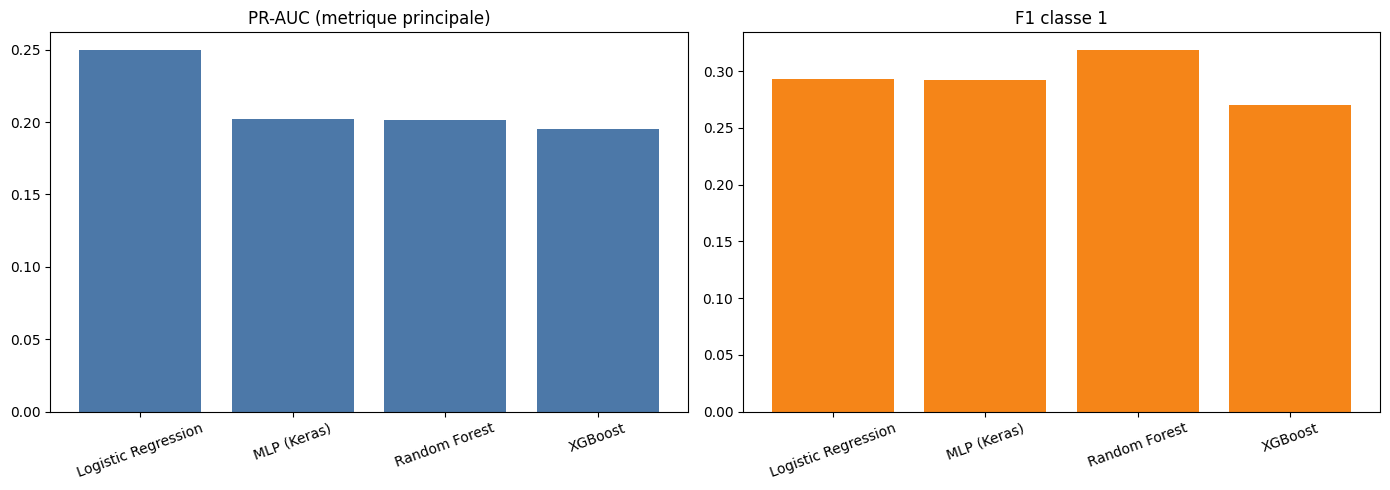

In [6]:
# Taches 1, 2, 3, 5: pipelines, CV, seuil optimal, comparaison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'recall': 'recall', 'f1': 'f1', 'average_precision': 'average_precision'}

results = []
threshold_tables = {}
trained_artifacts = {}

for model_name in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    preprocessor = build_preprocessor(selected_num, selected_cat, selected_flags)
    estimator = build_pipeline(model_name, preprocessor, pos_ratio)

    t0 = time.time()
    estimator.fit(X_train, y_train)
    train_time = time.time() - t0

    cv_raw = cross_validate(estimator, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_summary = {k: float(np.mean(v)) for k, v in cv_raw.items() if k.startswith('test_')}

    y_proba = estimator.predict_proba(X_test)[:, 1]
    row, table = evaluate_model(model_name, y_test, y_proba, train_time, cv_summary)

    results.append(row)
    threshold_tables[model_name] = table
    trained_artifacts[model_name] = estimator

if TF_AVAILABLE:
    cv_summary_mlp = cross_validate_mlp(X_train, y_train, selected_num, selected_cat, selected_flags)

    pre_mlp = build_preprocessor(selected_num, selected_cat, selected_flags)
    X_train_mlp = pre_mlp.fit_transform(X_train, y_train)
    X_test_mlp = pre_mlp.transform(X_test)

    if hasattr(X_train_mlp, 'toarray'):
        X_train_mlp = X_train_mlp.toarray()
        X_test_mlp = X_test_mlp.toarray()

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_mlp,
        y_train,
        test_size=0.2,
        stratify=y_train,
        random_state=RANDOM_STATE,
    )

    classes = np.array([0, 1])
    cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_tr)
    class_weight = {0: float(cw[0]), 1: float(cw[1])}

    mlp = build_mlp(X_train_mlp.shape[1])
    callbacks = [EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True)]

    t0 = time.time()
    mlp.fit(
        X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=256,
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=0,
    )
    train_time = time.time() - t0

    y_proba_mlp = mlp.predict(X_test_mlp, verbose=0).ravel()
    row, table = evaluate_model('MLP (Keras)', y_test, y_proba_mlp, train_time, cv_summary=cv_summary_mlp)

    results.append(row)
    threshold_tables['MLP (Keras)'] = table
    trained_artifacts['MLP (Keras)'] = {'preprocessor': pre_mlp, 'model': mlp}

results_df = pd.DataFrame(results).sort_values(['PR-AUC', 'F1_class1'], ascending=False)
display(results_df)

for model_name, table in threshold_tables.items():
    print(f'\nTable seuils - {model_name}')
    display(table.sort_values('seuil'))

plot_results(results_df)

In [7]:
# Sauvegarder le meilleur modele (classement PR-AUC puis F1)
root = find_project_root()
models_dir = root / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

best = results_df.iloc[0]
best_name = best['Model']
best_threshold = float(best['Optimal_threshold'])

if best_name == 'MLP (Keras)' and TF_AVAILABLE:
    artifact = trained_artifacts[best_name]
    keras_path = models_dir / 'best_model_mlp.keras'
    artifact['model'].save(keras_path)
    joblib.dump(
        {
            'model_name': best_name,
            'threshold': best_threshold,
            'preprocessor': artifact['preprocessor'],
            'features': selected_cols,
        },
        models_dir / 'best_model_meta.pkl',
    )
    print(f'MLP sauvegarde: {keras_path}')
else:
    payload = {
        'model_name': best_name,
        'threshold': best_threshold,
        'model': trained_artifacts[best_name],
        'features': selected_cols,
    }
    out = models_dir / 'best_model.pkl'
    joblib.dump(payload, out)
    print(f'Modele sauvegarde: {out}')

print('Best model:', best_name)

Modele sauvegarde: C:\Users\Héctor\OneDrive\Desktop\Projects\EFREI\M1-DE\PRO_DATA_SCIENCE\churn_predict\models\best_model.pkl
Best model: Logistic Regression
